## 1. Setup & Imports

In [85]:
import copy

import numpy as np

import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load & Filter Raw Data

In [83]:
df = pd.read_excel("../data/pacients_raw.xlsx")

df.columns = (
    df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"=\d+", "", regex=True)
        .str.replace(r"\W+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
)

RELEVANT_COLS = [
    "mr_area_cm2",
    "numeric_id",
    "la_area_cm2",
    "la_length_cm",
    "la_volume_ml",
    "mv_tenting_height_mm",
    "mv_annulus_mm",
    "lv_area_cm2",
    "lv_length_cm",
    "lv_volume_ml",
]

df.loc[df["systole_diastole"] == 1, RELEVANT_COLS].to_csv("../data/pacients_clean.csv", index=False)

## 3. Train/Val/Test Split & Preprocessing

In [137]:
FEATURE_COLS = [
    "la_area_cm2", "la_length_cm", "la_volume_ml",
    "mv_tenting_height_mm", "mv_annulus_mm",
    "lv_area_cm2", "lv_length_cm", "lv_volume_ml",
]
TARGET_COL = "mr_area_cm2"
GROUP_COL = "numeric_id"

df = pd.read_csv("../data/pacients_clean.csv")

gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss_outer.split(df, groups=df[GROUP_COL]))

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx].copy()

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss_inner.split(train_val_df, groups=train_val_df[GROUP_COL]))

train_df = train_val_df.iloc[train_idx].copy()
val_df   = train_val_df.iloc[val_idx].copy()

feature_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

train_df[FEATURE_COLS] = feature_pipeline.fit_transform(train_df[FEATURE_COLS])
val_df[FEATURE_COLS]   = feature_pipeline.transform(val_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = feature_pipeline.transform(test_df[FEATURE_COLS])

train_df.to_csv("../data/pacients_train.csv", index=False)
val_df.to_csv("../data/pacients_val.csv", index=False)
test_df.to_csv("../data/pacients_test.csv", index=False)

## 4. Common training setup

In [138]:
NUM_FEATURES = len(FEATURE_COLS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def to_tensors(df, feat_cols, tgt_col, dev):
    X = torch.tensor(df[feat_cols].values, dtype=torch.float32, device=dev)
    y = torch.tensor(df[tgt_col].values,  dtype=torch.float32, device=dev).unsqueeze(1)
    return X, y

X_train, y_train = to_tensors(train_df, FEATURE_COLS, TARGET_COL, device)
X_val, y_val = to_tensors(val_df, FEATURE_COLS, TARGET_COL, device)
X_test, y_test = to_tensors(test_df,  FEATURE_COLS, TARGET_COL, device)

## 5. First GNN Approach

Epoch   50/2000  total_loss=99.68478  (task_loss=79.54034, struct_loss=1.00722)  val_task_loss=25.60217  patience=0/50
Epoch  100/2000  total_loss=96.88020  (task_loss=78.72720, struct_loss=0.90765)  val_task_loss=25.41208  patience=0/50
Epoch  150/2000  total_loss=94.31566  (task_loss=77.81113, struct_loss=0.82523)  val_task_loss=25.20023  patience=0/50
Epoch  200/2000  total_loss=91.91831  (task_loss=76.80208, struct_loss=0.75581)  val_task_loss=24.96766  patience=0/50
Epoch  250/2000  total_loss=89.64767  (task_loss=75.71569, struct_loss=0.69660)  val_task_loss=24.71657  patience=0/50
Epoch  300/2000  total_loss=87.48103  (task_loss=74.57040, struct_loss=0.64553)  val_task_loss=24.45007  patience=0/50
Epoch  350/2000  total_loss=85.40486  (task_loss=73.38441, struct_loss=0.60102)  val_task_loss=24.17160  patience=0/50
Epoch  400/2000  total_loss=83.41087  (task_loss=72.17337, struct_loss=0.56187)  val_task_loss=23.88431  patience=0/50
Epoch  450/2000  total_loss=81.49297  (task_loss

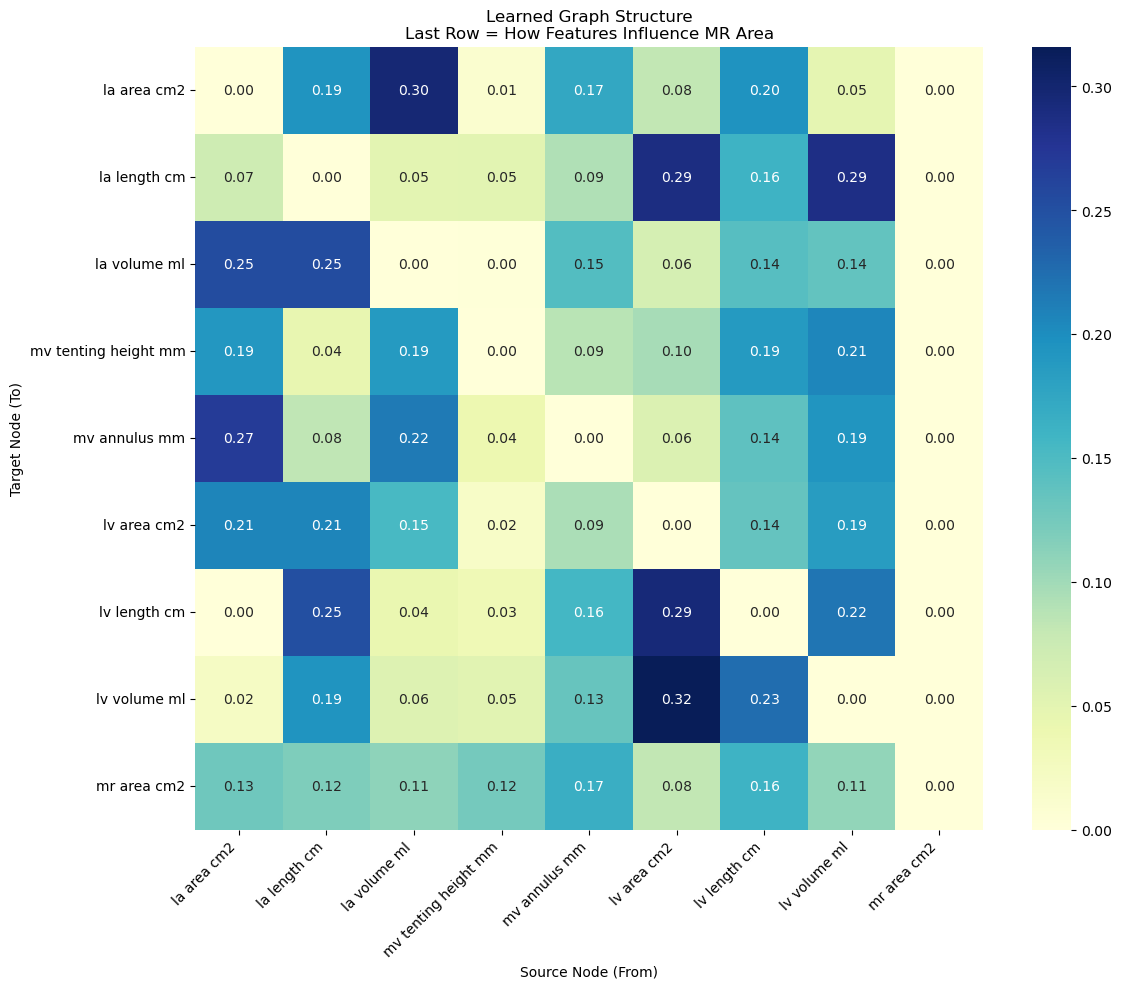

In [141]:
class SingleLayerGNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        n = num_features + 1
        self.num_features = num_features

        self.G = nn.Parameter(torch.randn(n, n) * 0.1)
        self.bias = nn.Parameter(torch.zeros(n))

        # mask: feature -> feature (no self-loops) and feature -> MR only
        mask = torch.zeros(n, n)
        mask[:num_features, :num_features] = 1.0
        mask.fill_diagonal_(0)
        mask[-1, :num_features] = 1.0
        self.register_buffer("mask", mask)

    def forward(self, x):
        h = torch.cat([x, x.new_zeros(x.size(0), 1)], dim=1)
        G_masked = self.G * self.mask
        # h = self.act(h @ G_masked.t() + self.bias)
        h = h @ G_masked.t() + self.bias
        mr_pred = F.softplus(h[:, -1:])
        feats_out = h[:, :self.num_features]
        return mr_pred, feats_out, G_masked

model = SingleLayerGNN(NUM_FEATURES).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
mse = nn.MSELoss()

MAX_EPOCHS = 2000
PATIENCE = 50
MIN_DELTA = 1e-4
LAMBDA = 20

best_val_task_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    mr_pred, feats_out, G_masked = model(X_train)
    task_loss = mse(mr_pred, y_train)
    struct_loss = mse(feats_out, X_train)
    total_loss = task_loss + LAMBDA * struct_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_task_loss = mse(model(X_val)[0], y_val).item()

    if val_task_loss < best_val_task_loss - MIN_DELTA:
        best_val_task_loss = val_task_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 50 == 0:
        print(f"Epoch {epoch:>4d}/{MAX_EPOCHS}  "
              f"total_loss={total_loss.item():.5f}  "
              f"(task_loss={task_loss.item():.5f}, struct_loss={struct_loss.item():.5f})  "
              f"val_task_loss={val_task_loss:.5f}  "
              f"patience={epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  "
              f"(best_val_task_loss = {best_val_task_loss:.5f})")
        break

model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    test_task_loss = mse(model(X_test)[0], y_test).item()
print(f"\ntest_task_loss: {test_task_loss:.5f}")

G_best = (model.G * model.mask).detach().cpu().numpy()
G_abs = np.abs(G_best)
G_norm = G_abs / (G_abs.sum(axis=1, keepdims=True) + 1e-8)

labels = [c.replace("_", " ") for c in FEATURE_COLS] + [TARGET_COL.replace("_", " ")]

plt.figure(figsize=(12, 10))
sns.heatmap(G_norm, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels)
plt.title("Learned Graph Structure\n"
          "Last Row = How Features Influence MR Area")
plt.xlabel("Source Node (From)")
plt.ylabel("Target Node (To)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Second GNN Approach

Epoch   50/2000  total_loss=99.95728  (task_loss=80.39505, struct_loss=0.97811)  val_task_loss=25.28793  patience=0/50
Epoch  100/2000  total_loss=98.30146  (task_loss=80.02718, struct_loss=0.91371)  val_task_loss=24.82141  patience=0/50
Epoch  150/2000  total_loss=95.44836  (task_loss=79.35478, struct_loss=0.80468)  val_task_loss=24.21904  patience=0/50
Epoch  200/2000  total_loss=91.41058  (task_loss=78.20317, struct_loss=0.66037)  val_task_loss=23.30261  patience=0/50
Epoch  250/2000  total_loss=86.89538  (task_loss=76.39024, struct_loss=0.52526)  val_task_loss=21.93698  patience=0/50
Epoch  300/2000  total_loss=82.30421  (task_loss=73.80130, struct_loss=0.42515)  val_task_loss=20.19538  patience=0/50
Epoch  350/2000  total_loss=77.68259  (task_loss=70.49149, struct_loss=0.35956)  val_task_loss=18.33702  patience=0/50
Epoch  400/2000  total_loss=72.86482  (task_loss=66.52522, struct_loss=0.31698)  val_task_loss=16.71433  patience=0/50
Epoch  450/2000  total_loss=67.77761  (task_loss

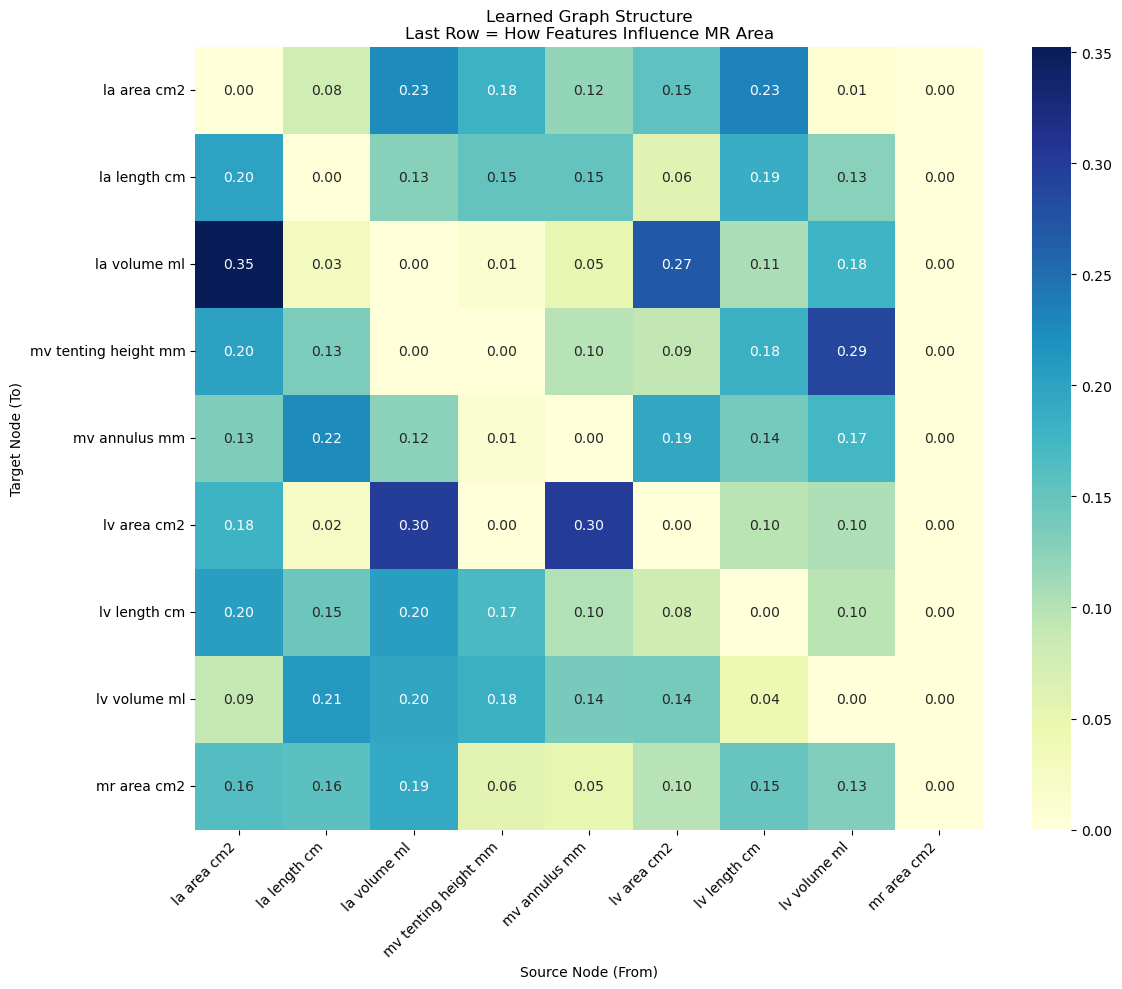

In [142]:
class MultipleLayerGNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        n = num_features + 1
        self.num_features = num_features

        self.G = nn.Parameter(torch.randn(n, n) * 0.1)
        self.bias1 = nn.Parameter(torch.zeros(n))
        self.bias2 = nn.Parameter(torch.zeros(n))
        
        self.act = nn.LeakyReLU(negative_slope=0.1)

        # mask: feature -> feature (no self-loops) and feature -> MR only
        mask = torch.zeros(n, n)
        mask[:num_features, :num_features] = 1.0
        mask.fill_diagonal_(0)
        mask[-1, :num_features] = 1.0
        self.register_buffer("mask", mask)

    def forward(self, x):
        h = torch.cat([x, x.new_zeros(x.size(0), 1)], dim=1)

        G_masked = self.G * self.mask

        h = self.act(h @ G_masked.t() + self.bias1)
        h = h @ G_masked.t() + self.bias2

        mr_pred = F.softplus(h[:, -1:])
        feats_out = h[:, :self.num_features]

        return mr_pred, feats_out, G_masked

model = MultipleLayerGNN(NUM_FEATURES).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
mse = nn.MSELoss()

MAX_EPOCHS = 2000
PATIENCE = 50
MIN_DELTA = 1e-4
LAMBDA = 20

best_val_task_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    mr_pred, feats_out, G_masked = model(X_train)
    task_loss = mse(mr_pred, y_train)
    struct_loss = mse(feats_out, X_train)
    total_loss = task_loss + LAMBDA * struct_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_task_loss = mse(model(X_val)[0], y_val).item()

    if val_task_loss < best_val_task_loss - MIN_DELTA:
        best_val_task_loss = val_task_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 50 == 0:
        print(f"Epoch {epoch:>4d}/{MAX_EPOCHS}  "
              f"total_loss={total_loss.item():.5f}  "
              f"(task_loss={task_loss.item():.5f}, struct_loss={struct_loss.item():.5f})  "
              f"val_task_loss={val_task_loss:.5f}  "
              f"patience={epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  "
              f"(best_val_task_loss = {best_val_task_loss:.5f})")
        break

model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    test_task_loss = mse(model(X_test)[0], y_test).item()
print(f"\ntest_task_loss: {test_task_loss:.5f}")

G_best = (model.G * model.mask).detach().cpu().numpy()
G_abs = np.abs(G_best)
G_norm = G_abs / (G_abs.sum(axis=1, keepdims=True) + 1e-8)

labels = [c.replace("_", " ") for c in FEATURE_COLS] + [TARGET_COL.replace("_", " ")]

plt.figure(figsize=(12, 10))
sns.heatmap(G_norm, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels)
plt.title("Learned Graph Structure\n"
          "Last Row = How Features Influence MR Area")
plt.xlabel("Source Node (From)")
plt.ylabel("Target Node (To)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()